# Детекция меланомы | Часть 3: Поиск гиперпараметров и обучение ViT-B/16

| | |
|---|---|
| **Датасет** | ISIC 2020 (33 126 изображений, менее 2% меланом) |
| **Задача** | Бинарная классификация: меланома / доброкачественное |
| **Архитектура** | ViT-Base/16 pretrained ImageNet-21k, full fine-tuning |
| **Главная метрика** | AUC-PR (Average Precision) |
| **Вспомогательные** | F1, Recall, Precision, Specificity, Balanced Accuracy |

---

## Структура ноутбука

Поиск лучших гиперпараметров ведётся автоматически через Optuna, затем лучшие конфигурации дообучаются на большем числе эпох.

| Блок | Что делается | Эпох |
|---|---|---|
| **1. Optuna** | Автоматический поиск гиперпараметров: оптимизатор, планировщик, lr, weight decay, dropout, label smoothing | 10 × 20 trials |
| **2. Топ-3** | Три лучшие конфигурации обучаются полноценно, сохраняются веса и метрики | 30 |
| **3. Финал** | Лучшая модель дообучается с early stopping (patience=7) | 50 |

## 1. Конфигурация и импорты

In [1]:
import os
import json
import random
import shutil
import time
import copy

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

import timm  # библиотека с предобученным ViT

from sklearn.metrics import (
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    confusion_matrix,
)

import optuna
from optuna.pruners import MedianPruner

from torch.cuda.amp import autocast, GradScaler

import IPython.display as ipd

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [3]:
# Пути к данным
IMAGE_DIR = "/kaggle/input/datasets/cdeotte/jpeg-melanoma-256x256/train"
TRAIN_CSV  = '/kaggle/input/datasets/daryanikitina/splitsss/split_train.csv'
VAL_CSV    = '/kaggle/input/datasets/daryanikitina/splitsss/split_val.csv'
TEST_CSV   = '/kaggle/input/datasets/daryanikitina/splitsss/split_test.csv'
OUTPUT_DIR = '/kaggle/working'

# DataLoader
IMAGE_SIZE  = 224   # ViT-B/16 принимает фиксированный размер 224×224
BATCH_SIZE  = 32
NUM_WORKERS = 2

In [29]:
# Optuna: база данных для сохранения trials между сессиями
STUDY_DB_PATH = '/kaggle/working/optuna_vit.db'
STUDY_NAME    = 'vit_base_stage1'

PREV_DB_PATH  = '/kaggle/input/datasets/daryanikitina/optuna-vit/optuna_vit.db'
# Блок 1: Optuna
N_TRIALS_TOTAL    = 15
OPTUNA_EPOCHS     = 15
# Останавливаю за 1 час до конца сессии Kaggle
TIME_BUDGET_HOURS = 10

# Блок 2: топ-3 на полные 30 эпох
NUM_EPOCHS_BLOCK2 = 30
TOP_K             = 3

# Блок 3: дообучение лучшей модели
NUM_EPOCHS_BLOCK3       = 50  # ещё 20 эпох поверх блока 2 (вместе 50)
EARLY_STOPPING_PATIENCE = 7

In [5]:
# Воспроизводимость: seed=42 везде
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

In [6]:
scaler = GradScaler()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

Устройство: cuda


## 2. Загрузка данных

In [7]:
class MelanomaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["image_name"] + ".jpg")
        image    = Image.open(img_path).convert("RGB")  # защита от RGBA/grayscale
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row["target"], dtype=torch.float32)  # float32 для BCEWithLogitsLoss
        return image, label

In [8]:
# Статистики нормализации ImageNet - ViT-B/16 pretrained на ImageNet-21k обучен с теми же значениями,
# поэтому входные данные нужно привести к тому же масштабу
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [9]:
# Для обучения базовая геометрическая аугментация из части 1
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMAGE_SIZE),    # случайный вырез вместо центрального
    transforms.RandomHorizontalFlip(),    # отражение по горизонтали (p=0.5)
    transforms.RandomVerticalFlip(),      # отражение по вертикали (p=0.5)
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Для валидации и теста нет аугментации
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [10]:
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

In [11]:
train_dataset = MelanomaDataset(train_df, IMAGE_DIR, transform=train_transform)
val_dataset   = MelanomaDataset(val_df,   IMAGE_DIR, transform=val_transform)
test_dataset  = MelanomaDataset(test_df,  IMAGE_DIR, transform=val_transform)

In [12]:
# Balanced batch
n_class0 = int((train_df['target'] == 0).sum())
n_class1 = int((train_df['target'] == 1).sum())
weight_class0  = 1.0 / n_class0
weight_class1  = 1.0 / n_class1
sample_weights = train_df['target'].map({0: weight_class0, 1: weight_class1}).values

sampler = WeightedRandomSampler(
    weights     = torch.FloatTensor(sample_weights),
    num_samples = len(train_dataset),
    replacement = True,  # с возвратом
)

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,
    num_workers = NUM_WORKERS,
    pin_memory  = False,
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = False,
)

print('\nDataLoader созданы:')
print('  Батчей в train:', len(train_loader))
print('  Батчей в val:  ', len(val_loader))
print('  Батчей в test: ', len(test_loader))


DataLoader созданы:
  Батчей в train: 777
  Батчей в val:   130
  Батчей в test:  130


## 3. Вспомогательные функции

In [14]:
class LabelSmoothingBCELoss(nn.Module):
    """
    BCEWithLogitsLoss с label smoothing (сглаживание меток).
    Стандартный BCE учит модель быть абсолютно уверенной, что ведёт к переобучению. Label smoothing 'размывает' жёсткие метки {0, 1}.
    В медицинских задачах метки могут быть зашумлены (спорные случаи на границе), поэтому небольшое сглаживание часто улучшает обобщение на новых данных.
    """
    def __init__(self, label_smoothing=0.0):
        super().__init__()
        self.ls  = label_smoothing
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        # Сдвигаю метки от краёв шкалы [0,1] ближе к центру
        soft_targets = targets * (1.0 - self.ls) + 0.5 * self.ls
        return self.bce(logits, soft_targets)

In [15]:
def make_vit(dropout=0.0):
    """
    Создаёт ViT-Small/16 с предобучением ImageNet-21k, заменяет классификационную голову.

    ViT-Small/16: изображение делится на патчи 16×16 пикселей - получается сетка 14×14 = 196 патчей.
    Каждый патч превращается в вектор (токен) и обрабатывается трансформером — как слова в BERT.
    Никаких свёрток нет: всё внимание (self-attention) между патчами.

    Small — облегчённая версия ViT (~22.1 млн параметров) против Base (~86.6 млн). Берём её, чтобы по числу
    параметров модель была сопоставима с ResNet-50 (~25.6 млн) и Swin-Tiny (~28 млн) — иначе сравнение архитектур
    превращается в сравнение "у кого модель в 3 раза больше", а не "какая архитектура эффективнее".

    Использую веса ImageNet-21k с дообучением на ImageNet-1k — тот же принцип, что и у Swin.
    drop_rate в timm управляет дропаутом внутри всей сети — на уровне встраиваний и MLP-блоков.
    num_classes=1 - заменяет стандартную голову на один выход (бинарная классификация без сигмоиды).
    """
    model = timm.create_model(
        'vit_small_patch16_224',  # ViT-Small, патчи 16×16, вход 224×224
        pretrained  = True,       # веса augreg_in21k_ft_in1k
        num_classes = 1,          # один выход - logit для BCEWithLogitsLoss
        drop_rate   = dropout,    # dropout внутри сети
    )
    return model

In [16]:
def compute_metrics(model, loader, criterion=None, threshold=None):
    """
    Прогоняет модель через весь DataLoader, считает все метрики качества.

    threshold=None  -> ищет лучший порог по F1 на переданных данных (для val).
    threshold=float -> применяет фиксированный порог без поиска (для test).
    """
    model.eval()
    all_probs  = []
    all_labels = []
    total_loss = 0.0
    n_batches  = 0 

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = model(images).squeeze(1)
            if criterion is not None:
                total_loss += criterion(logits, labels).item()
                n_batches  += 1
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    avg_loss = total_loss / n_batches if criterion is not None else None

    # Защита от вырожденного случая (все метки одного класса — бывает в начале обучения)
    if len(np.unique(all_labels)) < 2:
        auc_pr = 0.0
    else:
        # AUC-PR не зависит от порога — суммирует качество по всем возможным порогам
        auc_pr = float(average_precision_score(all_labels, all_probs))

    # Поиск порога, максимизирующего F1 — перебираю все 99 вариантов
    if threshold is None:
        best_f1  = -1.0
        best_thr = 0.5
        for thr in np.arange(0.01, 1.00, 0.01):
            preds_thr = (all_probs >= thr).astype(int)
            f1_thr    = f1_score(all_labels, preds_thr, zero_division=0.0)
            if f1_thr > best_f1:
                best_f1  = f1_thr
                best_thr = float(thr)
        threshold = best_thr

    preds = (all_probs >= threshold).astype(int)

    f1      = float(f1_score(all_labels, preds, zero_division=0.0))
    recall  = float(recall_score(all_labels, preds, zero_division=0.0))
    prec    = float(precision_score(all_labels, preds, zero_division=0.0))
    bal_acc = float(balanced_accuracy_score(all_labels, preds))

    cm = confusion_matrix(all_labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0

    return {
        'loss':              avg_loss, 
        'auc_pr':            auc_pr,
        'f1':                f1,
        'recall':            recall,
        'precision':         prec,
        'specificity':       specificity,
        'balanced_accuracy': bal_acc,
        'threshold':         threshold,
    }

In [17]:
def make_optimizer(params, model):
    """
    Создаёт оптимизатор по словарю params (от Optuna или сохранённому конфигу).

    Adam — стандарт; адаптивный lr для каждого параметра, хорошо работает 'из коробки'.
    AdamW — как Adam, но weight decay применяется правильно (не через lr, а отдельно). Предпочтителен для трансформеров:
    именно с AdamW обучались оригинальные ViT и BERT.
    """
    name = params['optimizer']
    lr   = params['lr']
    wd   = params['weight_decay']
    if name == 'Adam':
        return optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    else:  # AdamW
        return optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

In [18]:
def train_one_epoch(model, loader, optimizer, criterion, scheduler=None, scaler=None):
    """
    Обучает модель одну эпоху. Возвращает средний loss по батчам.

    OneCycleLR делает scheduler.step() после КАЖДОГО батча: lr-цикл рассчитан на точное число шагов = epochs x batches_per_epoch.
    Все остальные schedulers делают шаг 1 раз в конце эпохи.
    """
    model.train()
    total_loss = torch.zeros(1, device=DEVICE)  
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()

        # Mixed precision: вычисления в float16 вместо float32 — в 2 раза быстрее
        with autocast():
            logits = model(images).squeeze(1)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.detach()
        if scheduler is not None and isinstance(scheduler, optim.lr_scheduler.OneCycleLR):
            scheduler.step()
        del images, labels, logits, loss

    if scheduler is not None and not isinstance(scheduler, optim.lr_scheduler.OneCycleLR):
        scheduler.step()
    return (total_loss / len(loader)).item()

In [19]:
def make_scheduler(params, optimizer, n_epochs, steps_per_epoch):
    """
    Создаёт scheduler по словарю params.

    CosineAnnealingLR: плавно снижает lr по косинусу за T_max эпох, затем возвращается к максимуму. Хорошо работает с трансформерами.
    OneCycleLR: один цикл — lr сначала растёт (warmup) до max_lr, потом падает. Встроенный warmup особенно важен для ViT:
    трансформеры чувствительны к высокому lr в начале обучения, warmup позволяет избежать расхождения.

    n_epochs и steps_per_epoch используются только для OneCycleLR.
    """
    name = params['scheduler']
    lr   = params['lr']
    if name == 'CosineAnnealingLR':
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
    else:  # OneCycleLR
        return optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr          = lr,
            epochs          = n_epochs,
            steps_per_epoch = steps_per_epoch,
        )

In [20]:
def save_results(results, path):
    """
    Сохраняет список словарей в JSON.
    Ключ 'model' пропускается, так как это объект модели + показывает кликабельную ссылку для скачивания файла.
    """
    clean = [{k: v for k, v in r.items() if k != 'model'} for r in results]
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(clean, f, indent=2, ensure_ascii=False)
    print('Сохранено:', path)
    ipd.display(ipd.FileLink(path))


def display_db_link(path):
    """Выводит кликабельную ссылку для скачивания базы данных Optuna."""""
    print('База данных Optuna:', path)
    ipd.display(ipd.FileLink(path))

In [2]:
plt.rcParams.update({
    'figure.facecolor':     'white',
    'axes.facecolor':       'white',
    'axes.edgecolor':       '#111111',
    'axes.linewidth':       1.0,
    'axes.grid':            True,
    'grid.color':           '#cccccc',
    'grid.linewidth':       0.8,
    'grid.linestyle':       '--',
    'xtick.color':          '#111111',
    'ytick.color':          '#111111',
    'xtick.labelsize':      11,
    'ytick.labelsize':      11,
    'axes.labelsize':       12,
    'axes.labelcolor':      '#111111',
    'axes.titlesize':       14,
    'axes.titleweight':     'bold',
    'axes.titlecolor':      '#111111',
    'axes.titlepad':        14,
    'legend.framealpha':    1.0,
    'legend.edgecolor':     '#111111',
    'legend.fontsize':      11,
    'lines.linewidth':      2.5,
    'lines.markersize':     6,
    'savefig.dpi':          150,
    'savefig.bbox':         'tight',
    'savefig.facecolor':    'white',
})

# Палитра - контрастная, хорошо видна на проекторе
C1 = '#1f77b4'   # синий
C2 = '#d62728'   # красный
C3 = '#2ca02c'   # зелёный
C4 = '#ff7f0e'   # оранжевый
C5 = '#9467bd'   # фиолетовый
C6 = '#8c564b'   # коричневый
C_GRAY      = '#555555'
C_BLACK     = '#111111'

---
## 4. Автоматический поиск гиперпараметров - Optuna

**Что ищу:** optimizer, scheduler, lr, weight\_decay, dropout, label\_smoothing  
**Как:** каждый trial - одно обучение на `OPTUNA_EPOCHS=10` эпох  
**Метрика trial-а:** среднее val AUC-PR за последние 3 эпохи  
**MedianPruner:** срезает trial, если его метрика хуже медианы других на той же эпохе  
**SQLite:** trials сохраняются в `.db` — можно продолжить из следующей сессии Kaggle

In [23]:
# Настройка SQLite-хранилища и создание study
if PREV_DB_PATH is not None and os.path.exists(PREV_DB_PATH):
    shutil.copy(PREV_DB_PATH, STUDY_DB_PATH)
    print('Скопирована база из предыдущей сессии:', PREV_DB_PATH)
else:
    print('Начинаю новое исследование Optuna с нуля')

storage_url = 'sqlite:///' + STUDY_DB_PATH

# MedianPruner срезает trial, если его текущая метрика хуже медианы всех других
# n_startup_trials=5: первые 5 trials не трогаю — нужна база для сравнения
# n_warmup_steps=4: первые 4 эпохи каждого trial тоже не обрезаю — модель ещё учится
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=4)

study = optuna.create_study(
    study_name     = STUDY_NAME,
    storage        = storage_url,
    direction      = 'maximize',
    pruner         = pruner,
    load_if_exists = True,
)

already_done = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
print('Уже завершено trials:', len(already_done))

[I 2026-06-22 00:28:49,704] Using an existing study with name 'vit_base_stage1' instead of creating a new one.


Скопирована база из предыдущей сессии: /kaggle/input/datasets/daryanikitina/optuna-vit/optuna_vit.db
Уже завершено trials: 6


In [24]:
# Objective function и TimeBudgetCallback
def optuna_objective(trial):
    """
    Одна итерация Optuna: пробует набор параметров, обучает модель OPTUNA_EPOCHS эпох,
    возвращает среднее val AUC-PR за последние 3 эпохи как оценку качества.
    """
    # Optuna предлагает значения из заданных диапазонов
    # Для ViT: только Adam/AdamW — SGD плохо работает с трансформерами
    opt_name     = trial.suggest_categorical('optimizer',         ['Adam', 'AdamW'])
    # OneCycleLR предпочтителен для ViT: встроенный warmup защищает от расхождения в начале
    sched_name   = trial.suggest_categorical('scheduler',         ['CosineAnnealingLR', 'OneCycleLR'])
    # ViT требует меньший lr, чем CNN: трансформеры нестабильны при высоком lr
    lr           = trial.suggest_float('lr',            1e-5, 5e-4, log=True)
    # Трансформеры склонны к переобучению — weight decay важнее, чем для ResNet
    weight_decay = trial.suggest_float('weight_decay',  1e-4, 1e-1, log=True)
    # ViT уже имеет внутренний dropout — дополнительный не должен быть большим
    dropout      = trial.suggest_float('dropout',       0.0,  0.3)
    label_smooth = trial.suggest_float('label_smoothing', 0.0, 0.2)

    params = {
        'optimizer':       opt_name,
        'scheduler':       sched_name,
        'lr':              lr,
        'weight_decay':    weight_decay,
        'dropout':         dropout,
        'label_smoothing': label_smooth,
    }

    trial_model = make_vit(dropout=dropout).to(DEVICE)
    trial_opt   = make_optimizer(params, trial_model)
    trial_sched = make_scheduler(params, trial_opt, OPTUNA_EPOCHS, len(train_loader))
    criterion   = LabelSmoothingBCELoss(label_smoothing=label_smooth)

    val_auc_pr_history = []

    scaler = GradScaler()

    for epoch in range(OPTUNA_EPOCHS):
        train_one_epoch(trial_model, train_loader, trial_opt, criterion, trial_sched, scaler=scaler)
        metrics    = compute_metrics(trial_model, val_loader)
        val_auc_pr = metrics['auc_pr']
        val_auc_pr_history.append(val_auc_pr)

        trial.report(val_auc_pr, epoch)

        # Принудительный прунинг: если после 5-й эпохи среднее AUC-PR < 0.05, модель почти не лучше случайного классификатора
        if epoch >= 4:
            if float(np.mean(val_auc_pr_history)) < 0.05:
                del trial_model, trial_opt, trial_sched, criterion
                torch.cuda.empty_cache()
                raise optuna.TrialPruned()

        if trial.should_prune():
            del trial_model, trial_opt, trial_sched, criterion
            torch.cuda.empty_cache()
            raise optuna.TrialPruned()

    result_value = float(np.mean(val_auc_pr_history[-3:]))

    # Освобождаем GPU-память
    del trial_model, trial_opt, trial_sched, criterion
    torch.cuda.empty_cache()

    return result_value


class TimeBudgetCallback:
    """
    Останавливает Optuna, если исчерпан временной бюджет.
    Kaggle автоматически убивает сессию через 12 часов, поэтому нужно успеть сохраниться.
    """
    def __init__(self, hours):
        # момент времени, после которого нужно остановиться
        self.deadline = time.time() + hours * 3600.0

    def __call__(self, study, trial):
        if time.time() > self.deadline:
            print('Временной бюджет исчерпан - останавливаю Optuna.')
            study.stop()

In [25]:
# Запуск оптимизации + вывод результатов

time_callback = TimeBudgetCallback(TIME_BUDGET_HOURS)

already_done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
remaining = max(0, N_TRIALS_TOTAL - already_done)
print('Уже завершено: {} | Осталось запустить: {}'.format(already_done, remaining))

study.optimize(
    optuna_objective,
    n_trials          = remaining,
    callbacks         = [time_callback],
    show_progress_bar = True,
)

# Итоги
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned_trials    = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]

print('\n' + '='*70)
print('РЕЗУЛЬТАТЫ OPTUNA')
print('='*70)
print('Завершено: {} | Обрезано: {}'.format(len(completed_trials), len(pruned_trials)))

print('\nВсе завершённые trials (по убыванию метрики):')
for t in sorted(completed_trials, key=lambda x: x.value, reverse=True):
    print('  Trial {:3d} | val_auc_pr={:.4f} | {}'.format(t.number, t.value, t.params))

best = study.best_trial
print('\nЛучший trial: #{}'.format(best.number))
print('  Значение: {:.4f}'.format(best.value))
print('  Параметры:')
for k, v in best.params.items():
    print('    {}: {}'.format(k, v))

display_db_link(STUDY_DB_PATH)

Уже завершено: 6 | Осталось запустить: 9


  0%|          | 0/9 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

[I 2026-06-22 00:57:26,588] Trial 7 finished with value: 0.1761396705357735 and parameters: {'optimizer': 'AdamW', 'scheduler': 'OneCycleLR', 'lr': 0.00012860237299450647, 'weight_decay': 0.04011210943910604, 'dropout': 0.1373104560036039, 'label_smoothing': 0.042591524413013664}. Best is trial 0 with value: 0.25224634190936734.


[I 2026-06-22 01:26:15,495] Trial 8 finished with value: 0.29424883291597026 and parameters: {'optimizer': 'Adam', 'scheduler': 'CosineAnnealingLR', 'lr': 1.4529532800187913e-05, 'weight_decay': 0.0003773510051049561, 'dropout': 0.0894758997175556, 'label_smoothing': 0.062193182450003985}. Best is trial 8 with value: 0.29424883291597026.
[I 2026-06-22 01:55:01,090] Trial 9 finished with value: 0.2735940039594127 and parameters: {'optimizer': 'AdamW', 'scheduler': 'CosineAnnealingLR', 'lr': 1.3300130704197124e-05, 'weight_decay': 0.002662718541593232, 'dropout': 0.17327284703494705, 'label_smoothing': 0.19063484215310444}. Best is trial 8 with value: 0.29424883291597026.
[I 2026-06-22 02:23:52,979] Trial 10 finished with value: 0.21680547131676486 and parameters: {'optimizer': 'Adam', 'scheduler': 'CosineAnnealingLR', 'lr': 1.2167440980721154e-05, 'weight_decay': 0.00041329617458481634, 'dropout': 0.0813588530223068, 'label_smoothing': 0.10529548719495724}. Best is trial 8 with value: 0

/kaggle/working/optuna_vit.db

In [26]:
rows = []
for t in sorted(completed_trials, key=lambda x: x.value, reverse=True):
    row = {
        'Rank':         None,
        'Trial':        t.number,
        'AUC-PR (mean last 3)': round(t.value, 4),
        'optimizer':    t.params['optimizer'],
        'scheduler':    t.params['scheduler'],
        'lr':           round(t.params['lr'], 6),
        'weight_decay': round(t.params['weight_decay'], 6),
        'dropout':      round(t.params['dropout'], 3),
        'label_smooth': round(t.params['label_smoothing'], 3),
    }
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df['Rank'] = range(1, len(summary_df) + 1)
summary_df

,Rank,Trial,AUC-PR (mean last 3),optimizer,scheduler,lr,weight_decay,dropout,label_smooth
0,1,8,0.2942,Adam,CosineAnnealingLR,0.000015,0.000377,0.089,0.062
1,2,9,0.2736,AdamW,CosineAnnealingLR,0.000013,0.002663,0.173,0.191
2,3,0,0.2522,Adam,OneCycleLR,0.000028,0.000715,0.200,0.073
3,4,13,0.2476,AdamW,CosineAnnealingLR,0.000046,0.001446,0.096,0.133
4,5,11,0.2308,AdamW,CosineAnnealingLR,0.000011,0.004362,0.292,0.180
5,6,10,0.2168,Adam,CosineAnnealingLR,0.000012,0.000413,0.081,0.105
6,7,15,0.2130,Adam,CosineAnnealingLR,0.000034,0.000357,0.001,0.078
7,8,6,0.1905,AdamW,OneCycleLR,0.000161,0.001266,0.036,0.146
8,9,14,0.1836,AdamW,CosineAnnealingLR,0.000016,0.014738,0.060,0.077
9,10,1,0.1833,AdamW,CosineAnnealingLR,0.000055,0.004521,0.022,0.107


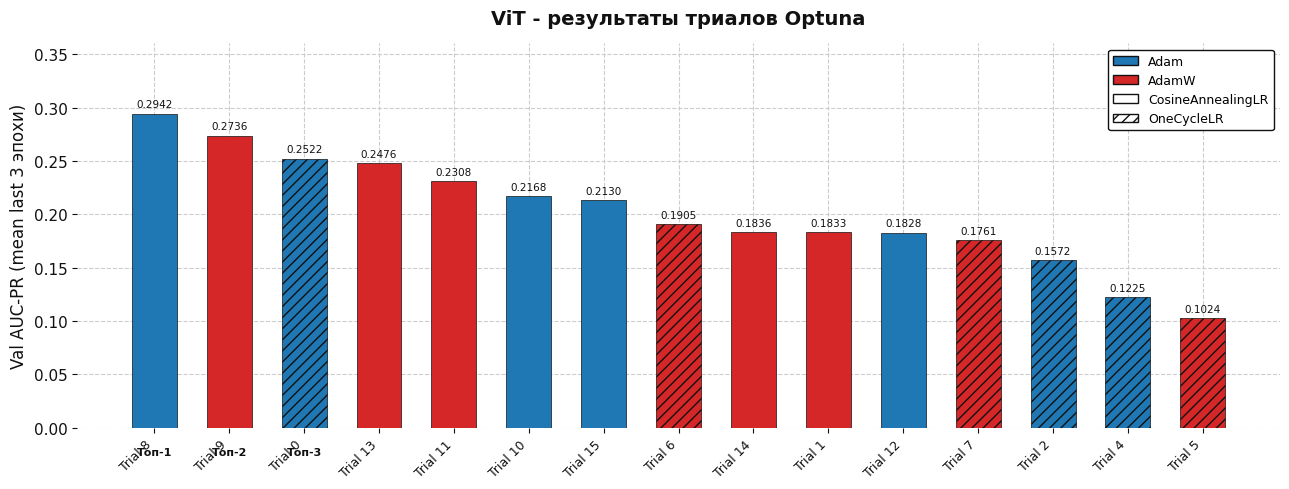

In [7]:
# График: результаты триалов Optuna, ViT

import numpy as np

trial_ids  = [8, 9, 0, 13, 11, 10, 15, 6, 14, 1, 12, 7, 2, 4, 5]
aucpr      = [0.2942, 0.2736, 0.2522, 0.2476, 0.2308, 0.2168, 0.2130,
              0.1905, 0.1836, 0.1833, 0.1828, 0.1761, 0.1572, 0.1225, 0.1024]
optimizers = ['Adam','AdamW','Adam','AdamW','AdamW','Adam','Adam',
              'AdamW','AdamW','AdamW','Adam','AdamW','Adam','Adam','AdamW']
schedulers = ['CosineAnnealingLR','CosineAnnealingLR','OneCycleLR','CosineAnnealingLR',
              'CosineAnnealingLR','CosineAnnealingLR','CosineAnnealingLR','OneCycleLR',
              'CosineAnnealingLR','CosineAnnealingLR','CosineAnnealingLR','OneCycleLR',
              'OneCycleLR','OneCycleLR','OneCycleLR']

# Цвет столбика - по оптимизатору, штриховка - по планировщику
bar_colors  = [C1 if o == 'Adam' else C2 for o in optimizers]
hatches     = ['' if s == 'CosineAnnealingLR' else '///' for s in schedulers]

x = np.arange(len(trial_ids))

fig, ax = plt.subplots(figsize=(13, 5))

for i, (val, color, hatch) in enumerate(zip(aucpr, bar_colors, hatches)):
    ax.bar(i, val, color=color, hatch=hatch, edgecolor='#111111', linewidth=0.5, width=0.6)

# Подписи значений над столбиками
for i, val in enumerate(aucpr):
    ax.text(i, val + 0.004, f'{val:.4f}', ha='center', va='bottom', fontsize=7.5, color='#111111')

# Топ-3 - подписываю отдельно
for i in range(3):
    ax.text(i, -0.018, f'Топ-{i+1}', ha='center', va='top', fontsize=8, color='#111111', fontweight='bold')

# Легенда вручную
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=C1, edgecolor='#111111', label='Adam'),
    Patch(facecolor=C2, edgecolor='#111111', label='AdamW'),
    Patch(facecolor='white', edgecolor='#111111', hatch='', label='CosineAnnealingLR'),
    Patch(facecolor='white', edgecolor='#111111', hatch='///', label='OneCycleLR'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'Trial {t}' for t in trial_ids], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Val AUC-PR (mean last 3 эпохи)')
ax.set_title('ViT - результаты триалов Optuna')
ax.set_ylim(0, 0.36)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig('vit_optuna_trials.png')
plt.show()

### ViT: подбор гиперпараметров через Optuna

**Топ-3 конфига по val AUC-PR:**
- Триал 8: AUC-PR = 0.2942, Adam + CosineAnnealingLR, lr = 1.5e-5, wd = 3.77e-4, dropout = 0.089, label_smooth = 0.062
- Триал 9: AUC-PR = 0.2736, AdamW + CosineAnnealingLR, lr = 1.3e-5, wd = 2.66e-3, dropout = 0.173, label_smooth = 0.191
- Триал 0: AUC-PR = 0.2522, Adam + OneCycleLR, lr = 2.8e-5, wd = 7.15e-4, dropout = 0.200, label_smooth = 0.073

**Наблюдения:**
- CosineAnnealingLR доминирует в топе - 8 из 10 лучших триалов используют его. OneCycleLR стабильно показывает худшие результаты, особенно при высоком lr.
- Лучшие lr сосредоточены в диапазоне 1e-5 - 5e-5. Триалы с lr > 1e-4 все попали в нижнюю половину рейтинга
- weight_decay у победителя очень маленький (3.77e-4) - сильная регуляризация ResNet-50 с pretrained весами не нужна
- Разброс между топ-1 (0.2942) и топ-15 (0.1024) большой - пространство гиперпараметров неоднородное

**Вывод:** беру топ-3 триала на расширенное обучение.

---
## 5. Топ-3 конфигурации оптуны на 20 эпох

Беру 3 лучших завершённых trial из Optuna. Каждый обучаю на `NUM_EPOCHS_BLOCK2=20` эпох с нуля. После каждой модели сохраняю `.pth` (веса + optimizer + scheduler) и `.json` с метриками. Все метрики выводятся на каждой эпохе.  
**Итоговая метрика модели:** среднее val AUC-PR за последние 3 эпохи.  

In [21]:
import shutil

# Копирую базу Optuna из прошлой сессии в рабочую папку
shutil.copy(
    '/kaggle/input/datasets/daryanikitina/optuna-vit-final/optuna_vit (2).db',
    '/kaggle/working/optuna_vit.db'
)
print('База скопирована')

База скопирована


In [22]:
storage_url = 'sqlite:///' + STUDY_DB_PATH

pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=4)

study = optuna.load_study(
    study_name = STUDY_NAME,
    storage    = storage_url,
)

completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
print('Загружено trials: {} завершённых'.format(len(completed)))
print('Лучший: Trial #{} | value={:.4f}'.format(study.best_trial.number, study.best_trial.value))

Загружено trials: 15 завершённых
Лучший: Trial #8 | value=0.2942


In [23]:
# Выбираю топ-K завершённых trials
completed_trials = sorted(
    [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
    key=lambda t: t.value,
    reverse=True,
)

if len(completed_trials) == 0:
    raise RuntimeError('Нет завершённых trials.')

top_k_trials = completed_trials[:TOP_K]
print('Топ-{} конфигураций для обучения:'.format(TOP_K))
for rank, t in enumerate(top_k_trials):
    print('  Rank {}: Trial #{} | optuna_val_auc_pr={:.4f}'.format(rank + 1, t.number, t.value))

# Загружаю уже сохранённые результаты (защита от перезапуска)
block2_json_path = os.path.join(OUTPUT_DIR, 'block2_results.json')

if os.path.exists(block2_json_path):
    with open(block2_json_path, 'r', encoding='utf-8') as f:
        block2_results = json.load(f)
    print('\nЗагружены результаты предыдущего запуска: {} моделей'.format(len(block2_results)))
else:
    block2_results = []

Топ-3 конфигураций для обучения:
  Rank 1: Trial #8 | optuna_val_auc_pr=0.2942
  Rank 2: Trial #9 | optuna_val_auc_pr=0.2736
  Rank 3: Trial #0 | optuna_val_auc_pr=0.2522


In [24]:
scaler = torch.cuda.amp.GradScaler()

# Обучаю каждую из топ-3 моделей
for rank, trial in enumerate(top_k_trials):
    trial_key  = 'trial_{}'.format(trial.number)
    rank_label = rank + 1  # 1, 2, 3

    # Проверяю, обучена ли уже эта модель в предыдущем запуске
    if any(r.get('trial_key') == trial_key for r in block2_results):
        print('\nRank {} (Trial #{}): уже обучена - пропускаю.'.format(
            rank_label, trial.number))
        continue

    params = trial.params
    print('\n' + '='*70)
    print('RANK {} | Trial #{} | Optuna val_auc_pr={:.4f}'.format(
        rank_label, trial.number, trial.value))
    print('Параметры: {}'.format(params))
    print('='*70)

    # Создаю модель, оптимизатор, планировщик, функцию потерь
    model     = make_vit(dropout=params['dropout']).to(DEVICE)
    optimizer = make_optimizer(params, model)
    scheduler = make_scheduler(params, optimizer, NUM_EPOCHS_BLOCK2, len(train_loader))
    criterion = LabelSmoothingBCELoss(label_smoothing=params['label_smoothing'])

    epoch_history      = []   # полная история всех метрик по эпохам
    val_auc_pr_history = []   # только AUC-PR для скользящего среднего

    for epoch in range(NUM_EPOCHS_BLOCK2):
        epoch_num = epoch + 1

        # Обучаю одну эпоху
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, scaler=scaler)

        # Все метрики на val (порог подбирается отдельно на каждой эпохе по F1)
        val_metrics = compute_metrics(model, val_loader, criterion=criterion, threshold=None)
        val_auc_pr_history.append(val_metrics['auc_pr'])

        # Скользящее среднее за последние 3 эпохи
        if epoch >= 2:
            sliding3     = float(np.mean(val_auc_pr_history[-3:]))
            sliding3_str = ' | sliding3={:.4f}'.format(sliding3)
        else:
            sliding3     = None
            sliding3_str = ''

        epoch_history.append({
            'epoch':            epoch_num,
            'train_loss':       round(train_loss, 6),
            'val_loss': round(val_metrics['loss'], 6),
            'val_auc_pr':       round(val_metrics['auc_pr'], 6),
            'val_f1':           round(val_metrics['f1'], 6),
            'val_recall':       round(val_metrics['recall'], 6),
            'val_precision':    round(val_metrics['precision'], 6),
            'val_specificity':  round(val_metrics['specificity'], 6),
            'val_balanced_acc': round(val_metrics['balanced_accuracy'], 6),
            'val_threshold':    round(val_metrics['threshold'], 4),
            'sliding_mean_3':   round(sliding3, 6) if sliding3 is not None else None,
        })

        # Вывод прогресса — все метрики на каждой эпохе
        print(
            'Ep {:2d}/{} | train_loss={:.4f} | val_loss={:.4f} | AUC-PR={:.4f} | F1={:.4f} | '
            'Rec={:.4f} | Prec={:.4f} | Spec={:.4f} | BalAcc={:.4f} | '
            'thr={:.2f}{}'.format(
                epoch_num, NUM_EPOCHS_BLOCK2,
                train_loss,
                val_metrics['loss'],
                val_metrics['auc_pr'],
                val_metrics['f1'],
                val_metrics['recall'],
                val_metrics['precision'],
                val_metrics['specificity'],
                val_metrics['balanced_accuracy'],
                val_metrics['threshold'],
                sliding3_str,
            )
        )

    # Ищу лучший порог на val — он будет применён к test
    final_val_metrics  = compute_metrics(model, val_loader, criterion=criterion, threshold=None)
    final_test_metrics = compute_metrics(model, test_loader, criterion=criterion,
                                     threshold=final_val_metrics['threshold'])

    mean_last3 = float(np.mean(val_auc_pr_history[-3:]))

    print('\nФинальные метрики (порог найден на val, применён к test):')
    print('  Val  | AUC-PR={:.4f} | F1={:.4f} | Rec={:.4f} | '
          'Prec={:.4f} | Spec={:.4f} | BalAcc={:.4f} | thr={:.2f}'.format(
        final_val_metrics['auc_pr'], final_val_metrics['f1'],
        final_val_metrics['recall'], final_val_metrics['precision'],
        final_val_metrics['specificity'], final_val_metrics['balanced_accuracy'],
        final_val_metrics['threshold']))
    print('  Test | AUC-PR={:.4f} | F1={:.4f} | Rec={:.4f} | '
          'Prec={:.4f} | Spec={:.4f} | BalAcc={:.4f}'.format(
        final_test_metrics['auc_pr'], final_test_metrics['f1'],
        final_test_metrics['recall'], final_test_metrics['precision'],
        final_test_metrics['specificity'], final_test_metrics['balanced_accuracy']))
    print('  Итоговая метрика (mean last-3 val AUC-PR): {:.4f}'.format(mean_last3))

    # Сохраняю чекпоинт
    ckpt_filename = 'block2_rank{}_trial{}.pth'.format(rank_label, trial.number)
    ckpt_path     = os.path.join(OUTPUT_DIR, ckpt_filename)
    torch.save({
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'params':               params,
        'val_auc_pr_history':   val_auc_pr_history,
        'epoch':                NUM_EPOCHS_BLOCK2,
        'trial_number':         trial.number,
        'rank':                 rank_label,
    }, ckpt_path)
    print('Веса сохранены:', ckpt_path)
    ipd.display(ipd.FileLink(ckpt_path))

    # Записываю результат в список
    def round_metrics(d):
        return {k: round(v, 6) if isinstance(v, float) else v for k, v in d.items()}

    block2_results.append({
        'trial_key':             trial_key,
        'rank':                  rank_label,
        'trial_number':          trial.number,
        'optuna_value':          round(trial.value, 6),
        'params':                params,
        'epoch_history':         epoch_history,
        'mean_last3_val_auc_pr': round(mean_last3, 6),
        'final_val_metrics':     round_metrics(final_val_metrics),
        'final_test_metrics':    round_metrics(final_test_metrics),
        'checkpoint_path':       ckpt_path,
    })

    # Сохраняю JSON сразу после каждой модели
    save_results(block2_results, block2_json_path)

    # Освобождаю GPU-память
    del model, optimizer, scheduler, criterion
    torch.cuda.empty_cache()


RANK 1 | Trial #8 | Optuna val_auc_pr=0.2942
Параметры: {'optimizer': 'Adam', 'scheduler': 'CosineAnnealingLR', 'lr': 1.4529532800187913e-05, 'weight_decay': 0.0003773510051049561, 'dropout': 0.0894758997175556, 'label_smoothing': 0.062193182450003985}


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Ep  1/30 | train_loss=0.3155 | val_loss=0.2558 | AUC-PR=0.2951 | F1=0.3385 | Rec=0.3014 | Prec=0.3860 | Spec=0.9914 | BalAcc=0.6464 | thr=0.89
Ep  2/30 | train_loss=0.1891 | val_loss=0.2007 | AUC-PR=0.2923 | F1=0.3766 | Rec=0.3973 | Prec=0.3580 | Spec=0.9872 | BalAcc=0.6922 | thr=0.62
Ep  3/30 | train_loss=0.1622 | val_loss=0.1935 | AUC-PR=0.3465 | F1=0.3932 | Rec=0.3151 | Prec=0.5227 | Spec=0.9948 | BalAcc=0.6550 | thr=0.79 | sliding3=0.3113
Ep  4/30 | train_loss=0.1557 | val_loss=0.2123 | AUC-PR=0.3219 | F1=0.3958 | Rec=0.5205 | Prec=0.3193 | Spec=0.9801 | BalAcc=0.7503 | thr=0.70 | sliding3=0.3202
Ep  5/30 | train_loss=0.1513 | val_loss=0.1878 | AUC-PR=0.3101 | F1=0.3721 | Rec=0.3288 | Prec=0.4286 | Spec=0.9921 | BalAcc=0.6605 | thr=0.54 | sliding3=0.3262
Ep  6/30 | train_loss=0.1454 | val_loss=0.1899 | AUC-PR=0.2755 | F1=0.3804 | Rec=0.4247 | Prec=0.3444 | Spec=0.9855 | BalAcc=0.7051 | thr=0.31 | sliding3=0.3025
Ep  7/30 | train_loss=0.1437 | val_loss=0.1864 | AUC-PR=0.3016 | F1=0.

/kaggle/working/block2_rank1_trial8.pth

Сохранено: /kaggle/working/block2_results.json


...

/kaggle/working/block2_results.json


RANK 3 | Trial #0 | Optuna val_auc_pr=0.2522
Параметры: {'optimizer': 'Adam', 'scheduler': 'OneCycleLR', 'lr': 2.8316570336091707e-05, 'weight_decay': 0.0007147687095611715, 'dropout': 0.199591909941794, 'label_smoothing': 0.07299807113218074}
Ep  1/30 | train_loss=0.5208 | val_loss=0.4706 | AUC-PR=0.2069 | F1=0.2535 | Rec=0.3699 | Prec=0.1929 | Spec=0.9722 | BalAcc=0.6710 | thr=0.86
Ep  2/30 | train_loss=0.3707 | val_loss=0.3622 | AUC-PR=0.2681 | F1=0.3270 | Rec=0.3562 | Prec=0.3023 | Spec=0.9853 | BalAcc=0.6707 | thr=0.91
Ep  3/30 | train_loss=0.2624 | val_loss=0.2860 | AUC-PR=0.2850 | F1=0.3492 | Rec=0.3014 | Prec=0.4151 | Spec=0.9924 | BalAcc=0.6469 | thr=0.93 | sliding3=0.2533
Ep  4/30 | train_loss=0.2167 | val_loss=0.2826 | AUC-PR=0.2713 | F1=0.3544 | Rec=0.3836 | Prec=0.3294 | Spec=0.9860 | BalAcc=0.6848 | thr=0.91 | sliding3=0.2748
Ep  5/30 | train_loss=0.2006 | val_loss=0.2566 | AUC-PR=0.3102 | F1=0.3621 | Rec=0.2877 | Prec=0.4884 | Spec=0.9946 | BalAcc=0.6411 | thr=0.94 | sl

/kaggle/working/block2_rank3_trial0.pth

Сохранено: /kaggle/working/block2_results.json


/kaggle/working/block2_results.json

In [25]:
# Итоговая таблица сравнения трёх моделей
print('\n' + '='*80)
print('ИТОГИ ЧАСТИ 5: СРАВНЕНИЕ ТОП-3 КОНФИГУРАЦИЙ')
print('='*80)

header = '{:<5} {:<10} {:<20} {:<12} {:<12} {:<12} {:<10}'.format(
    'Rank', 'Trial#', 'mean_last3_AUC-PR', 'Val AUC-PR', 'Test AUC-PR',
    'Test Recall', 'Test F1'
)
print(header)
print('-'*80)

for r in sorted(block2_results, key=lambda x: x['mean_last3_val_auc_pr'], reverse=True):
    print('{:<5} {:<10} {:<20.4f} {:<12.4f} {:<12.4f} {:<12.4f} {:<10.4f}'.format(
        r['rank'],
        r['trial_number'],
        r['mean_last3_val_auc_pr'],
        r['final_val_metrics']['auc_pr'],
        r['final_test_metrics']['auc_pr'],
        r['final_test_metrics']['recall'],
        r['final_test_metrics']['f1'],
    ))

best_b2 = max(block2_results, key=lambda r: r['mean_last3_val_auc_pr'])
print('\nЛучший по mean_last3_val_auc_pr:')
print('  Rank={} | Trial={} | mean_last3={:.4f} | Параметры: {}'.format(
    best_b2['rank'], best_b2['trial_number'],
    best_b2['mean_last3_val_auc_pr'], best_b2['params']))


ИТОГИ ЧАСТИ 5: СРАВНЕНИЕ ТОП-3 КОНФИГУРАЦИЙ
Rank  Trial#     mean_last3_AUC-PR    Val AUC-PR   Test AUC-PR  Test Recall  Test F1   
--------------------------------------------------------------------------------
2     9          0.2075               0.2064       0.2280       0.3699       0.3699    
1     8          0.2028               0.1943       0.2873       0.3425       0.3289    
3     0          0.1546               0.1545       0.1952       0.3151       0.2473    

Лучший по mean_last3_val_auc_pr:
  Rank=2 | Trial=9 | mean_last3=0.2075 | Параметры: {'optimizer': 'AdamW', 'scheduler': 'CosineAnnealingLR', 'lr': 1.3300130704197124e-05, 'weight_decay': 0.002662718541593232, 'dropout': 0.17327284703494705, 'label_smoothing': 0.19063484215310444}


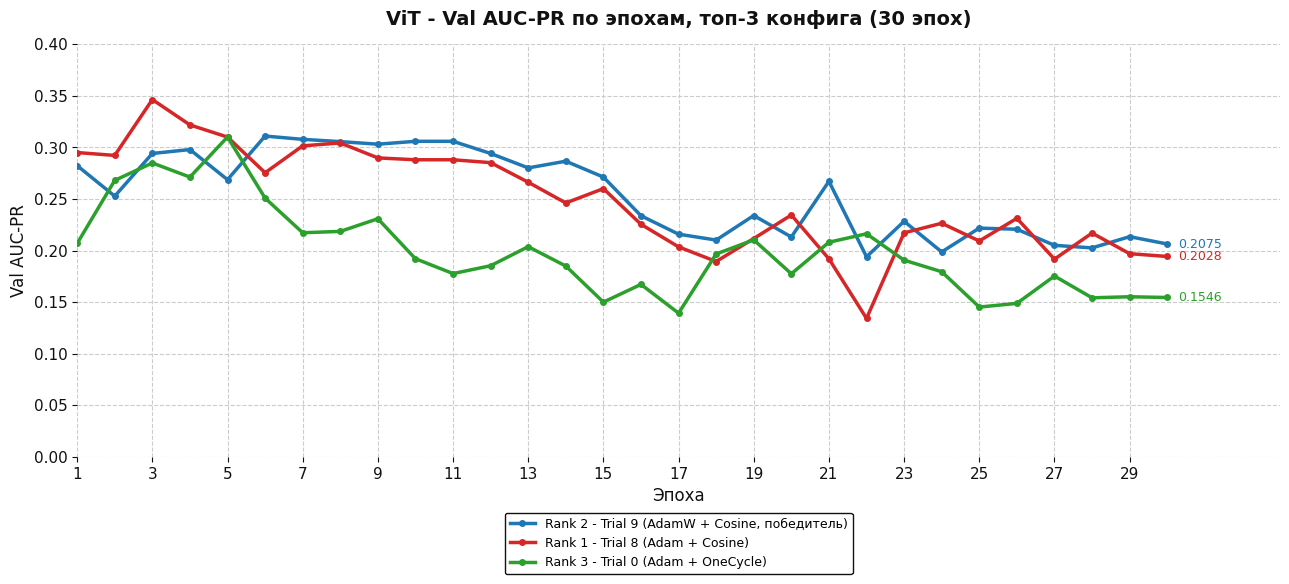

In [8]:
# График 1: val AUC-PR по эпохам, топ-3 конфига ViT

epochs = list(range(1, 31))

val_rank1 = [0.2951, 0.2923, 0.3465, 0.3219, 0.3101, 0.2755, 0.3016, 0.3044, 0.2899, 0.2881,
             0.2881, 0.2853, 0.2663, 0.2462, 0.2601, 0.2255, 0.2036, 0.1894, 0.2117, 0.2345,
             0.1920, 0.1342, 0.2172, 0.2265, 0.2093, 0.2313, 0.1917, 0.2170, 0.1970, 0.1943]

val_rank2 = [0.2824, 0.2528, 0.2942, 0.2980, 0.2688, 0.3111, 0.3079, 0.3057, 0.3032, 0.3060,
             0.3060, 0.2942, 0.2802, 0.2867, 0.2713, 0.2338, 0.2159, 0.2102, 0.2340, 0.2132,
             0.2672, 0.1940, 0.2284, 0.1987, 0.2218, 0.2207, 0.2051, 0.2026, 0.2135, 0.2064]

val_rank3 = [0.2069, 0.2681, 0.2850, 0.2713, 0.3102, 0.2509, 0.2173, 0.2186, 0.2309, 0.1921,
             0.1777, 0.1853, 0.2038, 0.1850, 0.1500, 0.1672, 0.1393, 0.1967, 0.2104, 0.1775,
             0.2081, 0.2163, 0.1907, 0.1795, 0.1452, 0.1488, 0.1753, 0.1542, 0.1552, 0.1545]

fig, ax = plt.subplots(figsize=(13, 6))

for vals, color, label, mean_last3 in [
    (val_rank2, C1, 'Rank 2 - Trial 9 (AdamW + Cosine, победитель)', '0.2075'),
    (val_rank1, C2, 'Rank 1 - Trial 8 (Adam + Cosine)',              '0.2028'),
    (val_rank3, C3, 'Rank 3 - Trial 0 (Adam + OneCycle)',            '0.1546'),
]:
    ax.plot(epochs, vals, color=color, marker='o', markersize=4, label=label)
    ax.annotate(mean_last3, xy=(30, vals[-1]), xytext=(30.3, vals[-1]),
                fontsize=9, color=color, va='center')

ax.set_xlabel('Эпоха')
ax.set_ylabel('Val AUC-PR')
ax.set_title('ViT - Val AUC-PR по эпохам, топ-3 конфига (30 эпох)')
ax.set_xticks(list(range(1, 31, 2)))
ax.set_xlim(1, 33)
ax.set_ylim(0, 0.40)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), frameon=True, fontsize=9, ncol=1)
plt.tight_layout()
plt.savefig('vit_top3_val_aucpr.png')
plt.show()

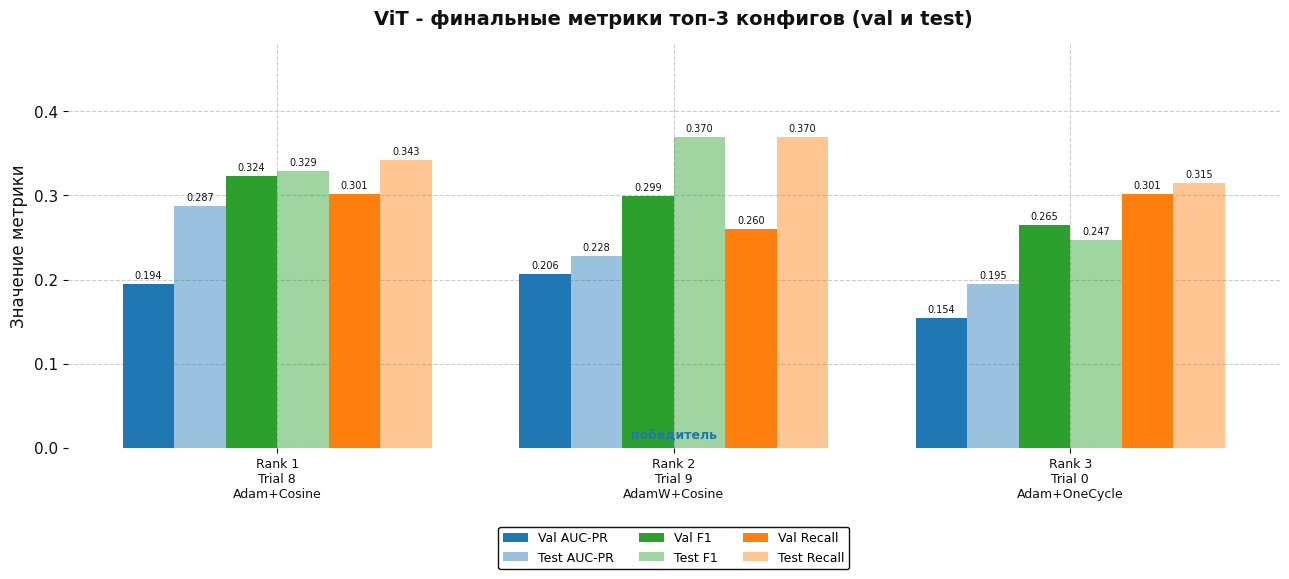

In [9]:
# График 2: столбчатый - val и test AUC-PR, F1, Recall для топ-3

import numpy as np

configs = ['Rank 1\nTrial 8\nAdam+Cosine', 'Rank 2\nTrial 9\nAdamW+Cosine', 'Rank 3\nTrial 0\nAdam+OneCycle']

val_aucpr  = [0.1943, 0.2064, 0.1545]
test_aucpr = [0.2873, 0.2280, 0.1952]
val_f1     = [0.3235, 0.2992, 0.2651]
test_f1    = [0.3289, 0.3699, 0.2473]
val_rec    = [0.3014, 0.2603, 0.3014]
test_rec   = [0.3425, 0.3699, 0.3151]

x     = np.arange(len(configs))
width = 0.13

fig, ax = plt.subplots(figsize=(13, 6))

bars = [
    ax.bar(x - 2.5*width, val_aucpr,  width, label='Val AUC-PR',  color=C1),
    ax.bar(x - 1.5*width, test_aucpr, width, label='Test AUC-PR', color=C1, alpha=0.45),
    ax.bar(x - 0.5*width, val_f1,     width, label='Val F1',      color=C3),
    ax.bar(x + 0.5*width, test_f1,    width, label='Test F1',      color=C3, alpha=0.45),
    ax.bar(x + 1.5*width, val_rec,    width, label='Val Recall',   color=C4),
    ax.bar(x + 2.5*width, test_rec,   width, label='Test Recall',  color=C4, alpha=0.45),
]

for bar_group in bars:
    for bar in bar_group:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7, color='#111111')
        
ax.text(1, 0.01, 'победитель', ha='center', fontsize=9, color=C1, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel('Значение метрики')
ax.set_title('ViT - финальные метрики топ-3 конфигов (val и test)')
ax.set_ylim(0, 0.48)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=True, fontsize=9, ncol=3)
plt.tight_layout()
plt.savefig('vit_top3_metrics_bar.png')
plt.show()

### ViT: расширенное обучение топ-3 конфигов (30 эпох)

**Результаты:**
- Rank 1 (Trial 8, Adam + Cosine, lr=1.45e-5): mean last3 = 0.2028 - пик на эпохе 3 (0.3465), затем деградация. CosineAnnealingLR "перегревает" модель во второй половине цикла
- Rank 2 (Trial 9, AdamW + Cosine, lr=1.33e-5): mean last3 = 0.2075 - наиболее стабильный из трёх, пик на эпохах 6-11 (0.31), затем плавное снижение
- Rank 3 (Trial 0, Adam + OneCycle, lr=2.83e-5): mean last3 = 0.1546 - OneCycleLR отрабатывает быстро, пик уже на эпохе 5 (0.3102), после чего модель не восстанавливается

**Победитель: Rank 2, Trial 9** - mean last3 val AUC-PR = 0.2075, наиболее стабильная динамика на длинном горизонте.

**Наблюдение:** все три конфига показывают значительно лучший результат на тесте чем на val в финале - это нормально, порог подбирается на val и переносится на test, но val AUC-PR в конце обучения ниже пикового значения из-за отсутствия early stopping на этом этапе.

---
## 6. Дообучение лучшей модели

Беру лучшую из топ-3 по **среднему val AUC-PR за последние 3 эпохи** из прошлой части. Загружаю её веса, optimizer и scheduler из чекпоинта части 5.  

**Критерий сохранения лучших весов:** максимальное скользящее среднее val AUC-PR за последние 3 эпохи из общей истории.  

**Early stopping:** patience=7 эпох без улучшения скользящего среднего. Счётчик ведётся от лучшего значения за **всё время** (включая предыдущую часть).  

**Первые 2 эпохи части 6 (глобально 21–22):** не сохраняю и не считаю patience. С 23-ей эпохи скользящее окно `[-3:]` заполнено только новыми эпохами.   

**Итоговая метрика для отчёта:** среднее val AUC-PR за последние 3 эпохи.

In [32]:
# Выбираю лучшую модель из топ-3 по среднему AUC-PR
best_b2 = max(block2_results, key=lambda r: r['mean_last3_val_auc_pr'])
print('Лучшая модель из части 5:')
print('  Rank={} | Trial={} | mean_last3_val_auc_pr={:.4f}'.format(
    best_b2['rank'], best_b2['trial_number'], best_b2['mean_last3_val_auc_pr']))
print('  Параметры: {}'.format(best_b2['params']))
print('  Загружаю из: {}'.format(best_b2['checkpoint_path']))

checkpoint = torch.load(best_b2['checkpoint_path'], map_location=DEVICE)
params     = checkpoint['params']

# Восстанавливаю модель с теми же параметрами, что в части 5
model = make_vit(dropout=params['dropout']).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])

# Восстанавливаю оптимизатор
optimizer = make_optimizer(params, model)
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Перемещаю оптимизатор на нужное устройство
for state in optimizer.state.values():
    for k, v in state.items():
        if isinstance(v, torch.Tensor):
            state[k] = v.to(DEVICE)

# Восстанавливаю scheduler и продолжаю с того места, где остановились в части 5
scheduler = make_scheduler(params, optimizer, NUM_EPOCHS_BLOCK3, len(train_loader))
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
print('Scheduler {} загружен из checkpoint.'.format(params['scheduler']))

criterion = LabelSmoothingBCELoss(label_smoothing=params['label_smoothing'])

# Инициализируем early stopping
# История AUC-PR из части 5 нужна, чтобы скользящее окно корректно работало
val_auc_pr_history = checkpoint['val_auc_pr_history']
print('Загружена история части 5, ({} эпох).'.format(len(val_auc_pr_history)))

# Начальное лучшее скользящее среднее из конца части 5
best_sliding_mean = float(np.mean(val_auc_pr_history[-3:]))
best_weights      = copy.deepcopy(model.state_dict())
patience_counter  = 0
best_epoch_global = NUM_EPOCHS_BLOCK2

print('Начальное лучшее скользящее среднее (конец части 5): {:.4f}'.format(best_sliding_mean))
print('Дообучаю {} эпох с early stopping (patience={}).\n'.format(
    NUM_EPOCHS_BLOCK3, EARLY_STOPPING_PATIENCE))

block3_epoch_history = []
early_stopped        = False

scaler = torch.cuda.amp.GradScaler()

for epoch in range(NUM_EPOCHS_BLOCK3):
    epoch_local  = epoch + 1
    epoch_global = NUM_EPOCHS_BLOCK2 + epoch + 1

    # Обучаю одну эпоху
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, scaler=scaler)

    # Все метрики на val
    val_metrics = compute_metrics(model, val_loader, criterion=criterion, threshold=None)
    val_auc_pr_history.append(val_metrics['auc_pr'])

    # Скользящее среднее за крайние 3 эпохи
    sliding_mean = float(np.mean(val_auc_pr_history[-3:]))

    # Звёздочкой отмечаю лучшее значение
    star = ''
    if epoch >= 2 and sliding_mean > best_sliding_mean:
        star = ' BEST'

    print(
        'Ep {:2d}/{} (glob {:2d}) | train_loss={:.4f} | val_loss={:.4f} | AUC-PR={:.4f} | F1={:.4f} | '
        'Rec={:.4f} | Prec={:.4f} | Spec={:.4f} | BalAcc={:.4f} | '
        'thr={:.2f} | AVG_3 AUC-PR={:.4f}{}'.format(
            int(epoch_local), int(NUM_EPOCHS_BLOCK3), int(epoch_global),
            train_loss,
            val_metrics['loss'],
            val_metrics['auc_pr'],
            val_metrics['f1'],
            val_metrics['recall'],
            val_metrics['precision'],
            val_metrics['specificity'],
            val_metrics['balanced_accuracy'],
            val_metrics['threshold'],
            sliding_mean,
            star,
        )
    )

    block3_epoch_history.append({
        'epoch_local':       epoch_local,
        'epoch_global':      epoch_global,
        'val_loss':          round(val_metrics['loss'], 6),
        'train_loss':        round(train_loss, 6),
        'val_auc_pr':        round(val_metrics['auc_pr'], 6),
        'val_f1':            round(val_metrics['f1'], 6),
        'val_recall':        round(val_metrics['recall'], 6),
        'val_precision':     round(val_metrics['precision'], 6),
        'val_specificity':   round(val_metrics['specificity'], 6),
        'val_balanced_acc':  round(val_metrics['balanced_accuracy'], 6),
        'val_threshold':     round(val_metrics['threshold'], 4),
        'sliding_mean_3':    round(sliding_mean, 6),
    })

    # Early stopping
    if epoch >= 2:
        if sliding_mean > best_sliding_mean:
            # Нашла лучшее скользящее среднее — сохраняю веса, сбрасываю терпение
            best_sliding_mean  = sliding_mean
            best_weights       = copy.deepcopy(model.state_dict())
            best_epoch_global  = epoch_global
            patience_counter   = 0
        else:
            patience_counter += 1

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print('\nEarly stopping: {} эпох без улучшения.'.format(
                EARLY_STOPPING_PATIENCE))
            print('Лучшие веса: глобальная эпоха {}.'.format(best_epoch_global))
            early_stopped = True
            break

# Загружаю лучшие веса
model.load_state_dict(best_weights)
print('\nЗагружены лучшие веса (глобальная эпоха {}).'.format(best_epoch_global))
print('Лучшее скользящее среднее val AUC-PR: {:.4f}'.format(best_sliding_mean))

Лучшая модель из части 5:
  Rank=2 | Trial=9 | mean_last3_val_auc_pr=0.2075
  Параметры: {'optimizer': 'AdamW', 'scheduler': 'CosineAnnealingLR', 'lr': 1.3300130704197124e-05, 'weight_decay': 0.002662718541593232, 'dropout': 0.17327284703494705, 'label_smoothing': 0.19063484215310444}
  Загружаю из: /kaggle/working/block2_rank2_trial9.pth
Scheduler CosineAnnealingLR загружен из checkpoint.
Загружена история части 5, (30 эпох).
Начальное лучшее скользящее среднее (конец части 5): 0.2075
Дообучаю 50 эпох с early stopping (patience=7).

Ep  1/50 (glob 31) | train_loss=0.3153 | val_loss=0.3436 | AUC-PR=0.2064 | F1=0.2992 | Rec=0.2603 | Prec=0.3519 | Spec=0.9914 | BalAcc=0.6258 | thr=0.12 | AVG_3 AUC-PR=0.2087
Ep  2/50 (glob 32) | train_loss=0.3153 | val_loss=0.3436 | AUC-PR=0.2093 | F1=0.3101 | Rec=0.2740 | Prec=0.3571 | Spec=0.9912 | BalAcc=0.6326 | thr=0.12 | AVG_3 AUC-PR=0.2073
Ep  3/50 (glob 33) | train_loss=0.3152 | val_loss=0.3434 | AUC-PR=0.2077 | F1=0.3235 | Rec=0.3014 | Prec=0.349

In [33]:
# Финальные метрики и сохранение результатов

# Порог подбираю на val с лучшими весами, применяем на test
final_val_metrics  = compute_metrics(model, val_loader,  criterion=criterion, threshold=None)
final_test_metrics = compute_metrics(model, test_loader, criterion=criterion,
                                     threshold=final_val_metrics['threshold'])

# Итоговая метрика для отчёта: среднее AUC-PR за последние 3 эпохи
last3_auc_pr      = [r['val_auc_pr'] for r in block3_epoch_history[-3:]]
mean_last3_block3 = float(np.mean(last3_auc_pr))

print('\n' + '='*70)
print('ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ЧАСТИ 6')
print('='*70)
print('Эпох дообучения: {} из {} | Early stopping: {}'.format(
    len(block3_epoch_history), NUM_EPOCHS_BLOCK3, early_stopped))
print('Лучшие веса: глобальная эпоха {}'.format(best_epoch_global))
print('Лучшее скользящее среднее val AUC-PR: {:.4f}'.format(best_sliding_mean))
print('Итоговая метрика (mean last-3 val AUC-PR ЧАСТИ 6): {:.4f}'.format(mean_last3_block3))

print('\nVal-метрики (порог={:.2f}):'.format(final_val_metrics['threshold']))
print('  AUC-PR={:.4f} | F1={:.4f} | Recall={:.4f} | Precision={:.4f} | '
      'Specificity={:.4f} | BalAcc={:.4f}'.format(
    final_val_metrics['auc_pr'],  final_val_metrics['f1'],
    final_val_metrics['recall'],  final_val_metrics['precision'],
    final_val_metrics['specificity'], final_val_metrics['balanced_accuracy']))

print('\nTest-метрики (порог с val={:.2f}):'.format(final_val_metrics['threshold']))
print('  AUC-PR={:.4f} | F1={:.4f} | Recall={:.4f} | Precision={:.4f} | '
      'Specificity={:.4f} | BalAcc={:.4f}'.format(
    final_test_metrics['auc_pr'],  final_test_metrics['f1'],
    final_test_metrics['recall'],  final_test_metrics['precision'],
    final_test_metrics['specificity'], final_test_metrics['balanced_accuracy']))

# Сохраняю веса финальной модели
final_model_path = os.path.join(OUTPUT_DIR, 'block3_final_model.pth')
torch.save({
    'model_state_dict':           best_weights,
    'params':                     params,
    'best_epoch_global':          best_epoch_global,
    'best_sliding_mean':          best_sliding_mean,
    'val_auc_pr_history_full':    val_auc_pr_history,
    'early_stopped':              early_stopped,
}, final_model_path)
print('\nВеса финальной модели сохранены:', final_model_path)
ipd.display(ipd.FileLink(final_model_path))

# Сохраняю результаты в JSON
def round_metrics(d):
    return {k: round(v, 6) if isinstance(v, float) else v for k, v in d.items()}

block3_results = [{
    'source_trial_number':          best_b2['trial_number'],
    'source_rank':                  best_b2['rank'],
    'params':                       params,
    'epochs_run_block3':            len(block3_epoch_history),
    'early_stopped':                early_stopped,
    'best_epoch_global':            best_epoch_global,
    'best_sliding_mean_val_auc_pr': round(best_sliding_mean, 6),
    'mean_last3_val_auc_pr_block3': round(mean_last3_block3, 6),
    'epoch_history_block3':         block3_epoch_history,
    'final_val_metrics':            round_metrics(final_val_metrics),
    'final_test_metrics':           round_metrics(final_test_metrics),
    'model_path':                   final_model_path,
}]

block3_json_path = os.path.join(OUTPUT_DIR, 'block3_results.json')
save_results(block3_results, block3_json_path)

print('\nФинальная модель обучена и сохранена.')


ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ЧАСТИ 6
Эпох дообучения: 14 из 50 | Early stopping: True
Лучшие веса: глобальная эпоха 37
Лучшее скользящее среднее val AUC-PR: 0.2236
Итоговая метрика (mean last-3 val AUC-PR ЧАСТИ 6): 0.1721

Val-метрики (порог=0.15):
  AUC-PR=0.2346 | F1=0.3605 | Recall=0.4247 | Precision=0.3131 | Specificity=0.9833 | BalAcc=0.7040

Test-метрики (порог с val=0.15):
  AUC-PR=0.2348 | F1=0.3459 | Recall=0.4384 | Precision=0.2857 | Specificity=0.9803 | BalAcc=0.7093

Веса финальной модели сохранены: /kaggle/working/block3_final_model.pth


/kaggle/working/block3_final_model.pth

Сохранено: /kaggle/working/block3_results.json


/kaggle/working/block3_results.json


Финальная модель обучена и сохранена.


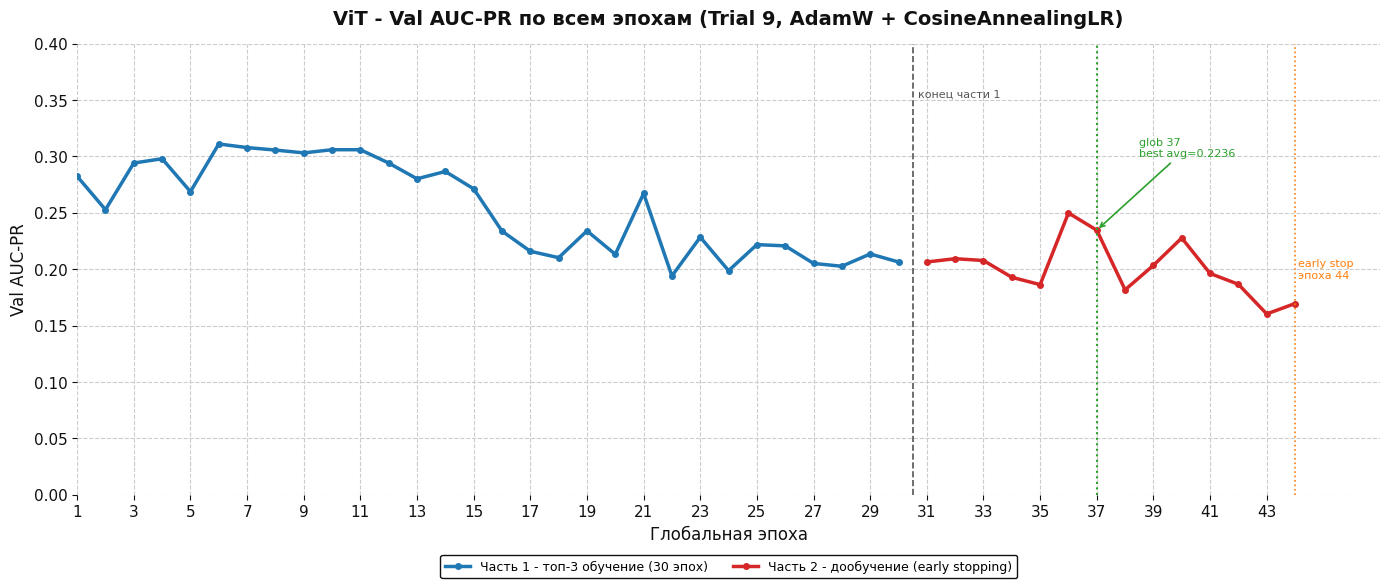

In [11]:
# График 1: сквозной val AUC-PR, ViT-Small - эпохи 1-44

epochs_p1 = list(range(1, 31))
epochs_p2 = list(range(31, 45))
epochs_all = epochs_p1 + epochs_p2

val_aucpr_p1 = [0.2824, 0.2528, 0.2942, 0.2980, 0.2688, 0.3111, 0.3079, 0.3057, 0.3032, 0.3060,
                0.3060, 0.2942, 0.2802, 0.2867, 0.2713, 0.2338, 0.2159, 0.2102, 0.2340, 0.2132,
                0.2672, 0.1940, 0.2284, 0.1987, 0.2218, 0.2207, 0.2051, 0.2026, 0.2135, 0.2064]

val_aucpr_p2 = [0.2064, 0.2093, 0.2077, 0.1928, 0.1863, 0.2499, 0.2346, 0.1817, 0.2034, 0.2277,
                0.1962, 0.1866, 0.1603, 0.1695]

val_aucpr_all = val_aucpr_p1 + val_aucpr_p2

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(epochs_p1,  val_aucpr_p1,  color=C1, marker='o', markersize=4, label='Часть 1 - топ-3 обучение (30 эпох)')
ax.plot(epochs_p2,  val_aucpr_p2,  color=C2, marker='o', markersize=4, label='Часть 2 - дообучение (early stopping)')

# Граница между частями
ax.axvline(30.5, color=C_GRAY, linewidth=1.2, linestyle='--')
ax.text(30.7, 0.36, 'конец части 1', fontsize=8, color=C_GRAY, va='top')

# Лучшая эпоха - glob 37 = локальная эпоха 7 части 2
ax.axvline(37, color=C3, linewidth=1.5, linestyle=':')
ax.annotate('glob 37\nbest avg=0.2236',
            xy=(37, val_aucpr_all[36]), xytext=(38.5, 0.30),
            arrowprops=dict(arrowstyle='->', color=C3, lw=1.2),
            fontsize=8, color=C3)

# Early stopping
ax.axvline(44, color=C4, linewidth=1.2, linestyle=':')
ax.text(44.1, 0.20, 'early stop\nэпоха 44', fontsize=8, color=C4, va='center')

ax.set_xlabel('Глобальная эпоха')
ax.set_ylabel('Val AUC-PR')
ax.set_title('ViT - Val AUC-PR по всем эпохам (Trial 9, AdamW + CosineAnnealingLR)')
ax.set_xticks(list(range(1, 45, 2)))
ax.set_xlim(1, 47)
ax.set_ylim(0, 0.40)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), frameon=True, fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('vit_full_val_aucpr.png')
plt.show()

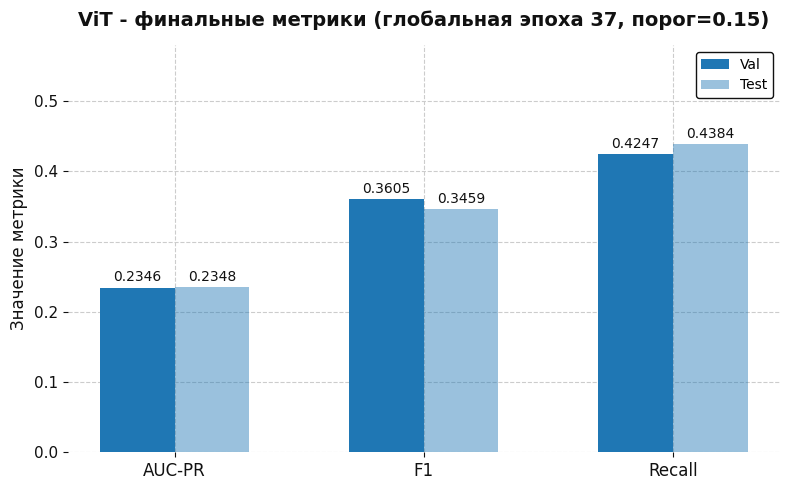

In [12]:
# График 2: столбчатый - val vs test, ViT финальные метрики

import numpy as np

metrics  = ['AUC-PR', 'F1', 'Recall']
val_vals  = [0.2346, 0.3605, 0.4247]
test_vals = [0.2348, 0.3459, 0.4384]

x     = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))

bars_val  = ax.bar(x - width/2, val_vals,  width, label='Val',  color=C1)
bars_test = ax.bar(x + width/2, test_vals, width, label='Test', color=C1, alpha=0.45)

for bars in [bars_val, bars_test]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.4f}', ha='center', va='bottom', fontsize=10, color='#111111')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Значение метрики')
ax.set_title('ViT - финальные метрики (глобальная эпоха 37, порог=0.15)')
ax.set_ylim(0, 0.58)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(frameon=True, fontsize=10)
plt.tight_layout()
plt.savefig('vit_final_metrics_bar.png')
plt.show()

 ### ViT: дообучение победителя до 50 эпох

Обучение остановилось на глобальной эпохе 44 - 7 эпох без улучшения скользящего среднего. Лучшие веса зафиксированы на глобальной эпохе 37 (avg=0.2236).

**Финальные метрики (порог=0.15, найден на val):**
- Val: AUC-PR=0.2346, F1=0.3605, Recall=0.4247
- Test: AUC-PR=0.2348, F1=0.3459, Recall=0.4384

Val и test AUC-PR практически совпадают (0.2346 vs 0.2348) - модель хорошо обобщается, переобучения нет. Recall 0.44 - отличный результат.